#### Objetivo: Aplicar diferentes modelos sobre os dados e analisar graficamente os resultados (mapa de magnetude e mapas de constelações)

In [1]:
# ---------------------
# Incluindo Bibliotecas
# ---------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VARMAX
from statsmodels.tsa.stattools import coint,kpss
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from itertools import product,combinations

#### Lendo Dados e Definindo Funções de Teste

In [2]:
# ---------------------------------------
# Função de Criação Automática de Lag (m)
# ---------------------------------------
def select_auto_lag(df_exog,exog_cols,max_x_lag=2,inplace=True) -> pd.DataFrame:
  """
  Aplica os lags desejado às exógenas da base de dados original e retorna o dataframe com as novas colunas
  """
  new_exog_cols = list(exog_cols)

  for lag in range(1, max_x_lag + 1):
    for col in exog_cols:
      lag_cols_name = f'{col}_lag{lag}'
      df_exog[lag_cols_name] = df_exog[col].shift(lag)
      new_exog_cols.append(lag_cols_name)

  lag_cols = [f'{col}_lag{lag}' for lag in range(1, max_x_lag+1) for col in exog_cols]
  rows_to_drop = df_exog.index[df_exog[lag_cols].isna().any(axis=1)]

  df_exog = df_exog.drop(index=rows_to_drop)
  return df_exog,new_exog_cols

In [3]:
# -------------------------------------------------
# Função de Seleção de grau de Polinômio de Lag (m)
# -------------------------------------------------
def select_auto_polinomial_degree(df_exog,exog_cols,degree_type,max_degree=1) -> pd.DataFrame:
  """
  Aplica os graus desejado às exógenas da base de dados original, gerando o polinômio completo para cada coluna
  das exógenas (originais e sem lags) e retorna o dataframe com as novas colunas
  """
  new_exog_cols = list(exog_cols)
  new_columns = {}

  if degree_type in ['real','r','REAL','Real']:
    degree_type = 'real'
  elif degree_type in ['img','i','IMG','Img']:
    degree_type = 'img'
  else:
    raise ValueError("degree_type must be 'real' or 'img'")

  # Aplicando graus para série de dados reais
  if max_degree >= 2:
    for degree in range(2, max_degree + 1):
      columns = [col for col in exog_cols if degree_type in col]
      for col in columns:
        degree_col_name = f'{col}_deg{degree}'
        new_columns[degree_col_name] = df_exog[col] ** degree
        new_exog_cols.append(degree_col_name)

  if new_columns:
    df_exog = pd.concat([df_exog,pd.DataFrame(new_columns,index=df_exog.index)],axis=1)

  return df_exog,new_exog_cols

In [4]:
data = "dadosIniciais.xlsx"
data = pd.read_excel(data)

In [5]:
df_input = pd.DataFrame()
df_input["Xreal"] = data.iloc[:,0]
df_input["Ximg"] = data.iloc[:,1]

In [6]:
df_output = pd.DataFrame()
df_output["Yreal"] = data.iloc[:,2]
df_output["Yimg"] = data.iloc[:,3]

In [7]:
df_concat = pd.concat([df_output,df_input],axis=1)

#### Teste de Treinamento do Modelo e Visualização dos Dados

In [8]:
# -------------------------------------
# Função de Seleção de Teste de Lag (m)
# -------------------------------------
def calc_train_sect(data:pd.DataFrame,train_frac:float,val_frac:float):
  """
  Calcula o tamanho dos conjuntos de treino, validação e teste
  """
  n = len(data)
  train_end = int(n*train_frac)
  val_end = int(n*(train_frac + val_frac))
  return train_end,val_end

# ----------------------------------------
# Treinamento do Modelo VARMAX customizado
# ----------------------------------------
def custom_train_varmax(
    df_train:pd.DataFrame,
    endog_lag,
    exog_lag,
    exog_img_degree,
    exog_real_degree,
    train_frac=0.6,
    val_frac=0.2,
    endog_cols=("Yreal","Yimg"),
    exog_cols=("Xreal", "Ximg")) -> VARMAX:
  """
  Treina o modelo VARMAX com base nos parâmetros fornecidos de lags para endógenas e exógenas e também
  com os graus dos polinômios de exógenas (real e imaginária)
  """
  train_end,val_end = calc_train_sect(df_train,train_frac,val_frac)
  df_temp = df_train.copy()
  current_exog_cols = list(exog_cols)

  if exog_lag > 0:
    df_temp,current_exog_cols = select_auto_lag(df_temp,exog_cols,max_x_lag=exog_lag)

  if exog_real_degree >= 2:
    df_temp, current_exog_cols = select_auto_polinomial_degree(df_temp,current_exog_cols,'r',max_degree=exog_real_degree)

  if exog_img_degree >= 2:
    df_temp, current_exog_cols = select_auto_polinomial_degree(df_temp,current_exog_cols,'i',max_degree=exog_img_degree)

  train = df_temp.iloc[:train_end].copy()
  val = df_temp.iloc[train_end:val_end].copy()
  test = df_temp.iloc[val_end:].copy()

  model = VARMAX(
          train[list(endog_cols)],
          exog=train[current_exog_cols],
          order=(endog_lag, 0),
          trend='c')

  res = model.fit(disp=False,maxiter=500,method="powell")

  return res,current_exog_cols,val

In [9]:
# ---------------------------------
# Geração dos Mapas de Constelações
# ---------------------------------
def drawn_constellation_map(forecast,endog_cols=('Yreal','Yimg'),title="Mapa de Constelação"):
  plt.figure(figsize=(6,6))
  plt.scatter(forecast[endog_cols[0]],forecast[endog_cols[1]],s=1,color='blue')
  plt.title(f"{title} - {endog_cols}")
  plt.xlabel("In-phase (I) [Y-Real]")
  plt.ylabel("Quadrature (Q) [Y-Img]")
  plt.grid(True)
  plt.axhline(0,color='black',lw=1)
  plt.axvline(0,color='black',lw=1)
  plt.show()

In [ ]:
# Treinando modelo com os seguintes parâmetros:
# p=1, xlag = 1, x_real_degree = 1, x_img_degree = 2
endog_cols = ["Yreal","Yimg"]
exog_cols =  ["Xreal","Ximg"]

res,current_exog_cols,val = custom_train_varmax(
    df_train=df_concat,
    endog_lag=1,
    exog_lag=1,
    exog_img_degree=2,
    exog_real_degree=1)

In [ ]:
fc = res.forecast(steps=len(val[list(endog_cols)]),exog=val[current_exog_cols])

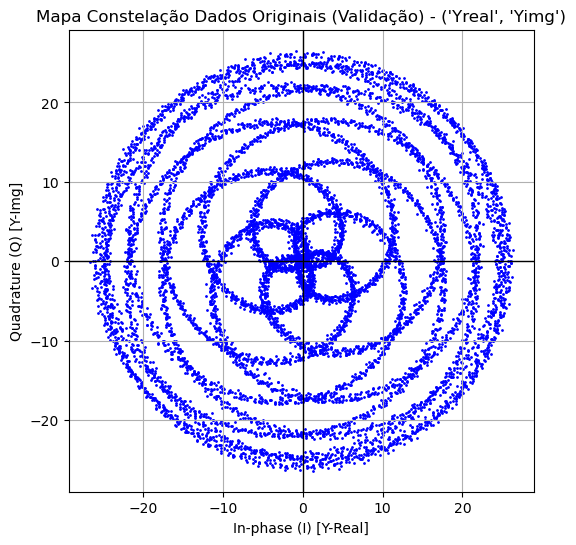

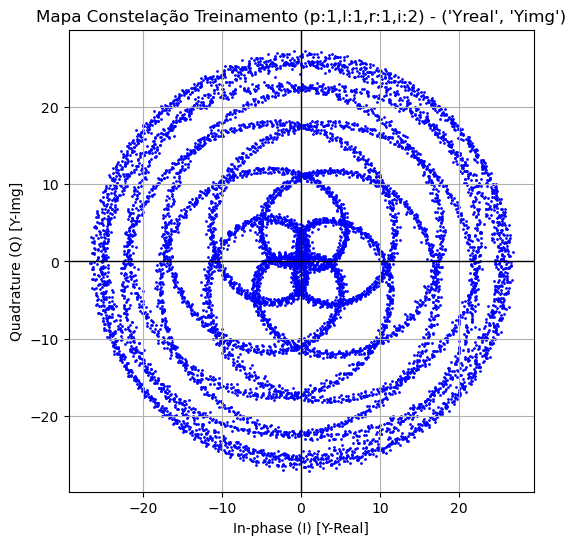

In [13]:
n = len(df_concat)
train_end,val_end = calc_train_sect(df_concat,0.6,0.2)
train = df_concat.iloc[:train_end].copy()
val = df_concat.iloc[train_end:val_end].copy()

drawn_constellation_map(val,title="Mapa Constelação Dados Originais (Validação)")
drawn_constellation_map(fc,title="Mapa Constelação Treinamento (p:1,l:1,r:1,i:2)")

#### Realizando Forecast Total dos Dados e Gerando Mapa de Magnetude

In [12]:
# ----------------------------
# Geração do Mapa de Magnetude
# ----------------------------
def drawn_magnitude_map(df_input,forecast,endog_cols=('Yreal','Yimg'),exog_cols=('Xreal','Ximg'),title="Mapa de Magnitude"):
  df_mag = pd.DataFrame()
  df_mag["MAG_Input"] = np.sqrt(df_input[exog_cols[0]]**2 + df_input[exog_cols[1]]**2)
  df_mag["MAG_Output_forecast"] = np.sqrt(forecast[endog_cols[0]]**2 + forecast[endog_cols[1]]**2)

  df_mag["MAG_Input_Decibel"] = 20*np.log10(df_mag["MAG_Input"])
  df_mag["MAG_Output_Decibel_forecast"] = 20*np.log10(df_mag["MAG_Output_forecast"])

  plt.plot(df_mag["MAG_Input_Decibel"],df_mag["MAG_Output_Decibel_forecast"],marker='o')
  plt.xlabel("MAG Input [dB]")
  plt.ylabel("MAG Output Forecast [dB]")
  plt.title(f"{title} - Y-Forecast em função de X")
  plt.grid(True)
  plt.show()

In [ ]:
# Treinando Modelo
# Modelo: p=1, xlag = 1, x_real_degree = 1, x_img_degree = 2
endog_cols = ["Yreal","Yimg"]
exog_cols = ["Xreal","Ximg"]

final_res,_,_ = custom_train_varmax(
    df_train=df_concat,
    endog_lag=1,
    exog_lag=1,
    exog_img_degree=1,
    exog_real_degree=2)

In [ ]:
# Realizando o forecast de todos os dados
df_final = df_concat.copy()
df_final,current_exog_cols = select_auto_lag(df_final,exog_cols,max_x_lag=1)
df_final,current_exog_cols = select_auto_polinomial_degree(df_final,current_exog_cols,'r',max_degree=1)
df_final,current_exog_cols = select_auto_polinomial_degree(df_final,current_exog_cols,'i',max_degree=2)

endog_total = df_final[list(["Yreal","Yimg"])]
exog_total = df_final[list(current_exog_cols)]

['Yreal', 'Yimg', 'Xreal', 'Ximg', 'Xreal_lag1', 'Ximg_lag1', 'Ximg_deg2', 'Ximg_lag1_deg2']


In [19]:
fc_total = final_res.forecast(steps=len(endog_total),exog=exog_total)
fc_total.index = endog_total.index

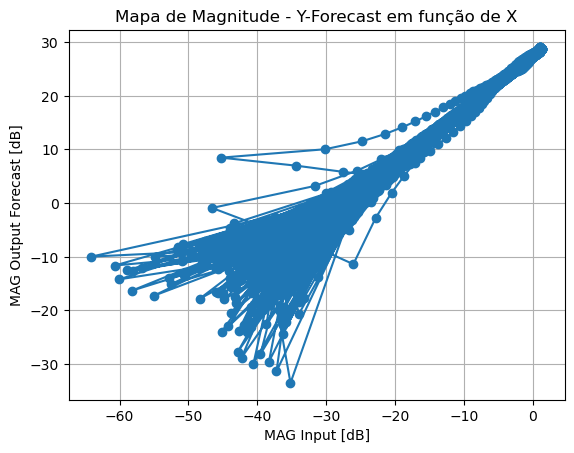

In [20]:
# Gerando Mapa de Magnetude
drawn_magnitude_map(df_concat,fc_total)

In [ ]:
# Treinando Modelo
# Modelo: p=1, xlag = 1, x_real_degree = 1, x_img_degree = 2
endog_cols = ["Yreal","Yimg"]
exog_cols = ["Xreal","Ximg"]

final_res,_,_ = custom_train_varmax(
    df_train=df_concat,
    endog_lag=1,
    exog_lag=2,
    exog_img_degree=2,
    exog_real_degree=1)

In [ ]:
# Realizando o forecast de todos os dados
df_final = df_concat.copy()
df_final,current_exog_cols = select_auto_lag(df_final,exog_cols,max_x_lag=1)
df_final,current_exog_cols = select_auto_polinomial_degree(df_final,current_exog_cols,'r',max_degree=1)
df_final,current_exog_cols = select_auto_polinomial_degree(df_final,current_exog_cols,'i',max_degree=2)

print(f"{list(df_final.columns)}")

endog_total = df_final[list(["Yreal","Yimg"])]
exog_total = df_final[list(current_exog_cols)]

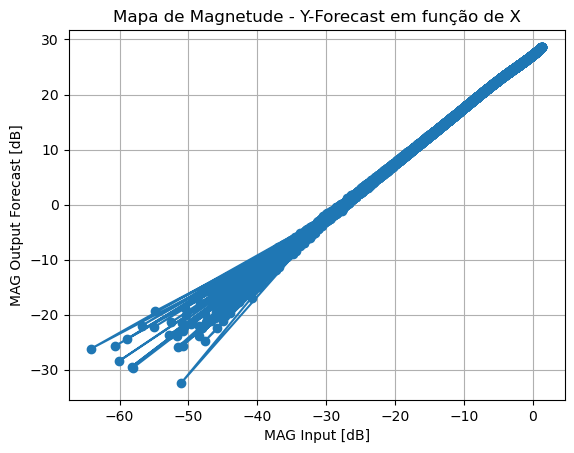

In [ ]:
# Mapa de Magnetude dos dados originais
drawn_magnitude_map(df_concat,df_concat)

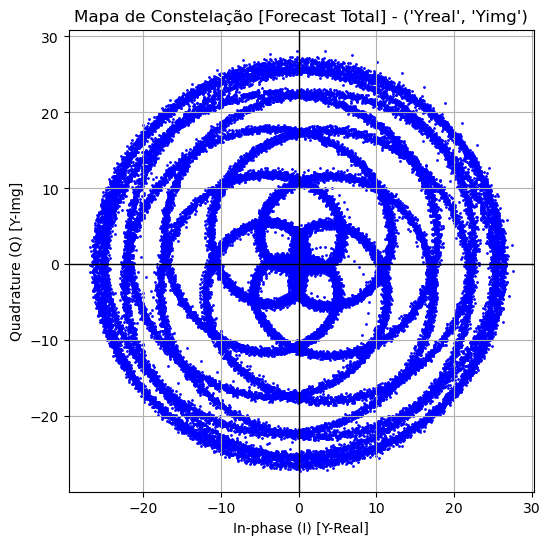

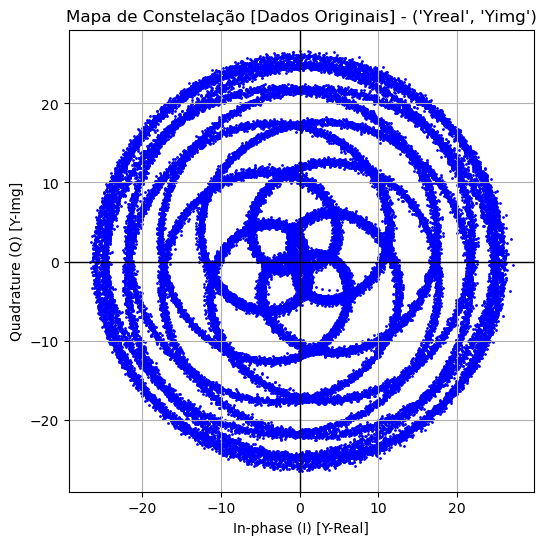

In [ ]:
# Mapa de constelação do forecast dos dados totais e dos dados totais originais
drawn_constellation_map(fc_total,title="Mapa de Constelação [Forecast Total]")
drawn_constellation_map(df_concat,title="Mapa de Constelação [Dados Originais]")